# Exploratory Data Analysis and Cleaning

This notebook examines the course dataset using the accompanying codebook and produces `data/data_processed.csv` from the unchanged `data/data.csv`. It documents data-quality findings, applies deterministic cleaning rules, and checks the export.

Missing-value imputation, scaling, and categorical encoding are intentionally deferred to the training-only modeling pipeline.

## Analysis workflow

The notebook loads and validates the raw schema, reports missing and invalid values, documents each cleaning decision, and examines class, questionnaire, and demographic distributions. It then checks the cleaned dataset and writes the modeling input. Counts and charts are generated from the data rather than from a manual Data Wrangler export.

Key operations include pandas masks and grouped summaries, `drop_duplicates()`, and Matplotlib/Seaborn visualizations. Assertions stop execution if the input or cleaned output violates expected constraints. Code comments explain less-obvious operations at the point of use.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

DATA_PATH = Path("data/data.csv")
CODEBOOK_PATH = Path("data/codebook.txt")
PROCESSED_PATH = Path("data/data_processed.csv")

# Keep the domain assumptions visible in one place.
TARGET_COLUMN = "target"
DEMOGRAPHIC_COLUMNS = ["age", "gender", "hand"]
VALID_RESPONSE_VALUES = {1, 2, 3, 4, 5}
MAX_PLAUSIBLE_AGE = 100


## 1. Load raw data and check the schema

In [2]:
raw_df = pd.read_csv(DATA_PATH)
question_columns = [
    column
    for column in raw_df.columns
    if column not in DEMOGRAPHIC_COLUMNS + [TARGET_COLUMN]
]

assert len(question_columns) == 19, "Expected 19 questionnaire features."
assert raw_df[TARGET_COLUMN].notna().all(), "The target must not be missing."

print(f"Raw data shape: {raw_df.shape}")
print(f"Questionnaire features ({len(question_columns)}): {question_columns}")
raw_df.dtypes

Raw data shape: (19719, 23)
Questionnaire features (19): ['N6', 'N8', 'N7', 'N1', 'N9', 'N10', 'N3', 'N5', 'E3', 'N2', 'E5', 'N4', 'E7', 'E4', 'C4', 'E1', 'A4', 'E10', 'E9']


N6        int64
N8        int64
N7        int64
N1        int64
N9        int64
N10       int64
N3        int64
N5        int64
E3        int64
N2        int64
E5        int64
N4        int64
E7        int64
E4        int64
age       int64
C4        int64
E1        int64
A4        int64
E10       int64
E9        int64
gender      str
hand        str
target      str
dtype: object

## 2. Inspect data before cleaning

Data Wrangler was used for an initial visual review. The tables below reproduce the key findings in code, so the notebook remains understandable without that interface.

In [3]:
# Record missing values, categories, and fully duplicated rows before changing any data.
missing_before_cleaning = raw_df.isna().sum()

inspection_summary = pd.DataFrame(
    {
        "Finding": [
            "Rows",
            "Columns",
            "Questionnaire features",
            "Missing values in gender",
            "Missing values in hand",
            "Age values above 100",
            "Fully duplicated rows",
        ],
        "Count": [
            len(raw_df),
            raw_df.shape[1],
            len(question_columns),
            missing_before_cleaning["gender"],
            missing_before_cleaning["hand"],
            (raw_df["age"] > MAX_PLAUSIBLE_AGE).sum(),
            raw_df.duplicated().sum(),
        ],
    }
)
inspection_summary

,Finding,Count
0,Rows,19719
1,Columns,23
2,Questionnaire features,19
3,Missing values in gender,24
4,Missing values in hand,100
5,Age values above 100,83
6,Fully duplicated rows,3


In [4]:
# Compare the observed category values against the codebook.
for column in ["gender", "hand", TARGET_COLUMN]:
    print(f"{column}:")
    print(raw_df[column].value_counts(dropna=False))
    print()

# According to the codebook, only responses 1 through 5 are valid.
invalid_question_values = ~raw_df[question_columns].isin(VALID_RESPONSE_VALUES)
invalid_question_rows = invalid_question_values.any(axis=1)
all_zero_questionnaire = raw_df[question_columns].eq(0).all(axis=1)

print(f"Rows with at least one invalid questionnaire value: {invalid_question_rows.sum()}")
print(f"Rows with 0 in all 19 questions: {all_zero_questionnaire.sum()}")

gender:
gender
Female    11985
Male       7608
Other       102
NaN          24
Name: count, dtype: int64

hand:
hand
Right    17424
Left      1724
Both       471
NaN        100
Name: count, dtype: int64

target:
target
Moderate           8452
Resilient          6163
Overcontroller     2829
Undercontroller    2275
Name: count, dtype: int64

Rows with at least one invalid questionnaire value: 1
Rows with 0 in all 19 questions: 1


## 3. Documented cleaning decisions

1. Remove a row with `0` in **all** 19 questions: the codebook does not allow `0`, and this questionnaire has no valid answers.
2. Treat ages above 100 as missing: some values resemble birth years, but no verified survey year supports converting them into ages.
3. Keep missing values in `gender` and `hand` unchanged.
4. Remove fully duplicated rows, keeping the first occurrence.

In [5]:
# Stop if invalid questionnaire values do not match the documented all-zero case.
assert invalid_question_rows.sum() == all_zero_questionnaire.sum(), (
    "Invalid questionnaire values extend beyond the documented all-zero case."
)

In [6]:
# Remove only the questionnaire with no valid answers at all.
cleaned_df = raw_df.loc[~all_zero_questionnaire].copy()
removed_all_zero_rows = int(all_zero_questionnaire.sum())

# Nullable Int64 keeps age numeric while allowing missing values.
cleaned_df["age"] = cleaned_df["age"].astype("Int64")
invalid_age = cleaned_df["age"] > MAX_PLAUSIBLE_AGE
invalid_age_count = int(invalid_age.sum())
cleaned_df.loc[invalid_age, "age"] = pd.NA

# drop_duplicates() keeps the first row of each identical group.
before_duplicates = len(cleaned_df)
cleaned_df = cleaned_df.drop_duplicates().copy()
removed_duplicate_rows = before_duplicates - len(cleaned_df)

print(f"Removed questionnaires with no valid answers: {removed_all_zero_rows}")
print(f"Implausible ages marked as missing: {invalid_age_count}")
print(f"Removed fully duplicated rows: {removed_duplicate_rows}")
print(f"Shape after cleaning: {cleaned_df.shape}")

Removed questionnaires with no valid answers: 1
Implausible ages marked as missing: 83
Removed fully duplicated rows: 3
Shape after cleaning: (19715, 23)


## 4. Target classes and class balance

The distribution is shown after the documented cleaning because this dataset is used for modeling. Class shares alone do not determine resampling or model parameters; they motivate evaluating all classes with macro F1.

In [7]:
# A fixed order makes the table and chart comparable across runs.
TARGET_ORDER = [
    "Moderate",
    "Resilient",
    "Overcontroller",
    "Undercontroller",
]

target_summary = (
    cleaned_df[TARGET_COLUMN]
    .value_counts()
    .reindex(TARGET_ORDER)
    .rename_axis("Personality type")
    .to_frame("Count")
)
target_summary["Share (%)"] = (
    target_summary["Count"] / len(cleaned_df) * 100
).round(2)
target_summary


,Count,Share (%)
Personality type,,
Moderate,8449,42.86
Resilient,6162,31.26
Overcontroller,2829,14.35
Undercontroller,2275,11.54


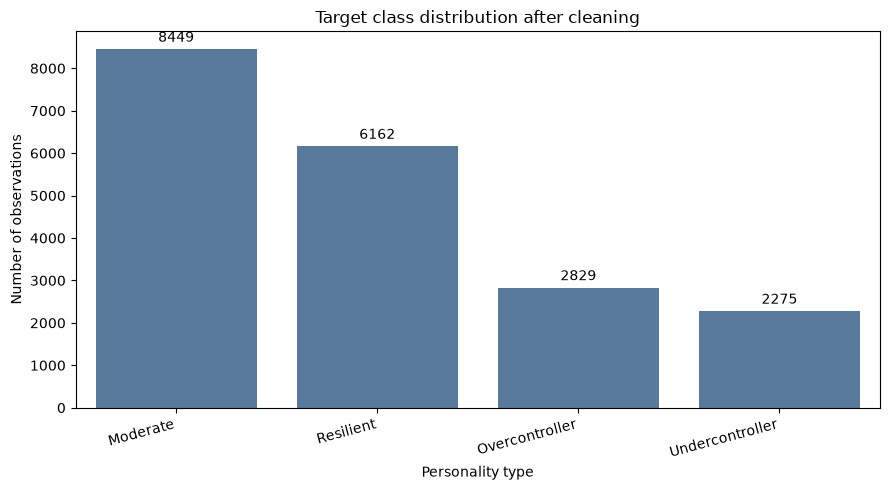

In [8]:
# The bar chart shows absolute class counts without implying a modeling choice.
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=target_summary.reset_index(),
    x="Personality type",
    y="Count",
    color="#4C78A8",
)
ax.set_title("Target class distribution after cleaning")
ax.set_xlabel("Personality type")
ax.set_ylabel("Number of observations")
ax.bar_label(ax.containers[0], padding=3)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


## 5. Questionnaire response distributions

The 19 questions use a Likert scale from 1 to 5. Response shares are therefore shown for each level. A single mean would hide potentially different response patterns.

In [9]:
LIKERT_ORDER = [1, 2, 3, 4, 5]

# Each row represents a question and each column a response level.
# After cleaning, all questionnaire feature values are valid.
question_response_counts = pd.DataFrame(
    {value: cleaned_df[question_columns].eq(value).sum() for value in LIKERT_ORDER}
)
question_response_counts.index.name = "Question"

# Percentages remain comparable if the number of rows changes later.
question_response_shares = (
    question_response_counts.div(question_response_counts.sum(axis=1), axis=0) * 100
).round(2)
question_response_shares.columns = [f"Response {value} (%)" for value in LIKERT_ORDER]
question_response_shares


,Response 1 (%),Response 2 (%),Response 3 (%),Response 4 (%),Response 5 (%)
Question,,,,,
N6,16.09,23.85,22.04,21.99,16.03
N8,21.66,24.07,20.50,19.86,13.91
N7,12.37,22.22,21.94,24.79,18.68
N1,11.45,19.68,21.93,25.10,21.84
N9,13.11,21.68,21.24,26.54,17.43
N10,19.37,24.57,22.59,20.29,13.19
N3,4.37,10.61,15.88,34.67,34.47
N5,15.00,25.20,22.76,23.72,13.31
E3,8.20,16.55,23.76,28.34,23.14


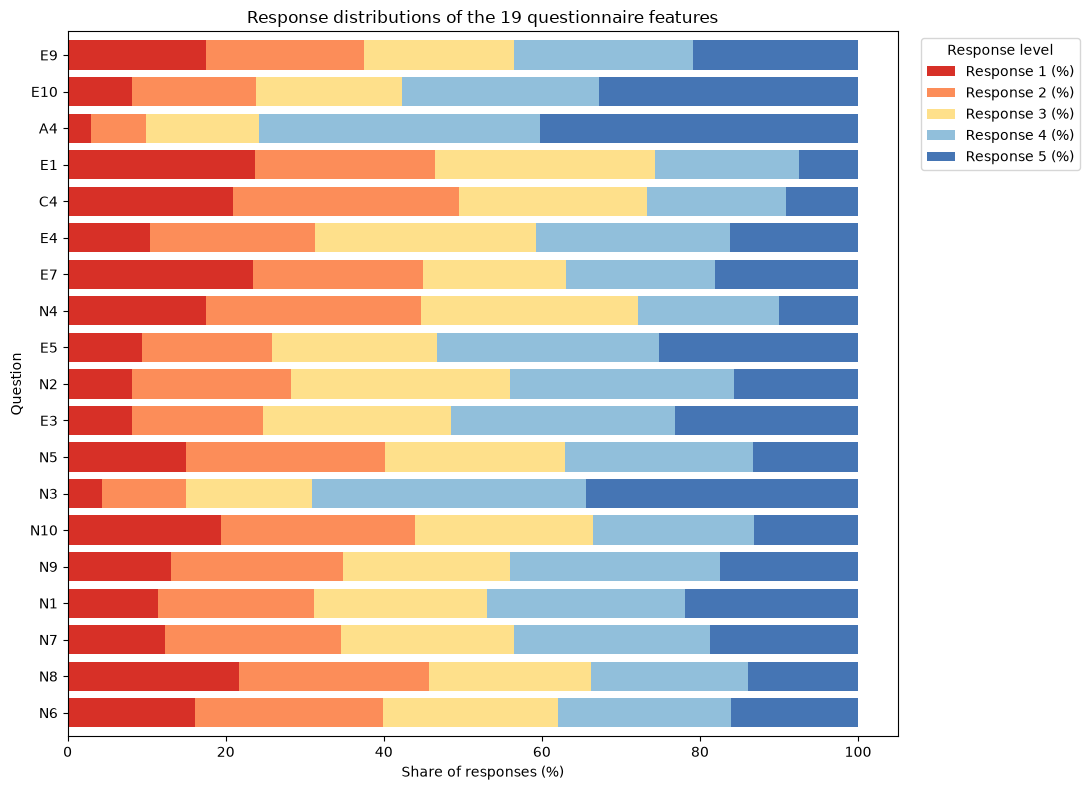

In [10]:
# A 100%-stacked bar chart shows the shape of each response distribution.
response_colors = ["#D73027", "#FC8D59", "#FEE08B", "#91BFDB", "#4575B4"]
ax = question_response_shares.plot(
    kind="barh",
    stacked=True,
    figsize=(11, 8),
    color=response_colors,
    width=0.8,
)
ax.set_title("Response distributions of the 19 questionnaire features")
ax.set_xlabel("Share of responses (%)")
ax.set_ylabel("Question")
ax.legend(title="Response level", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Observations

Response patterns differ across questions: `A4` (sympathy for others' feelings) and `N3` (worry) have the highest shares of responses 4 and 5. For `C4` (messiness), `E1` (being the center of attention at parties), and `N8` (frequent mood swings), responses 1 and 2 are more common. All response levels occur in all 19 questions; no question is constant or needs to be removed for that reason.

These are raw answers to differently worded statements. High agreement cannot be interpreted as a high or low trait value without the statement's wording. According to the codebook, reverse scoring was used when the target class was originally constructed and is not repeated here. These distributions do not justify an additional cleaning or feature-selection rule.

## 6. Demographic features

The following summaries use the cleaned dataset. Missing values are shown but not filled in. Imputation belongs in the fitted preprocessing pipeline later.

In [11]:
# describe() summarizes observed ages; missing values remain visible separately.
age_summary = cleaned_df["age"].describe().to_frame(name="age")
age_summary.loc["missing", "age"] = cleaned_df["age"].isna().sum()
age_summary.loc["missing (%)", "age"] = (
    cleaned_df["age"].isna().mean() * 100
).round(2)
age_summary


,age
count,19632.0
mean,26.263346
std,11.566972
min,13.0
25%,18.0
50%,22.0
75%,31.0
max,100.0
missing,83.0
missing (%),0.42


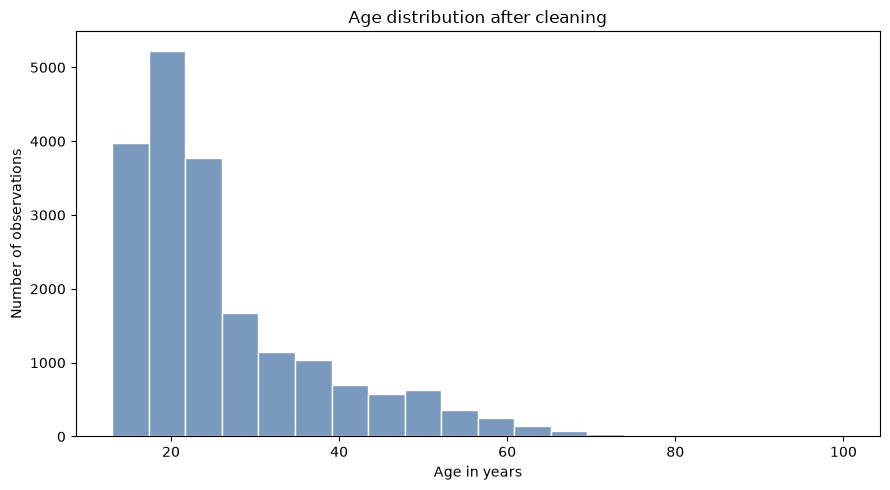

In [12]:
# A histogram is more informative for numeric age than a separate bar for each value.
plt.figure(figsize=(9, 5))
sns.histplot(cleaned_df["age"].dropna(), bins=20, color="#4C78A8", edgecolor="white")
plt.title("Age distribution after cleaning")
plt.xlabel("Age in years")
plt.ylabel("Number of observations")
plt.tight_layout()
plt.show()


In [13]:
# Age bands provide a readable description of the sample only.
age_band = pd.cut(
    cleaned_df["age"],
    bins=[0, 17, 24, 34, 44, 54, 64, 100],
    labels=["<=17", "18-24", "25-34", "35-44", "45-54", "55-64", "65-100"],
    include_lowest=True,
)
age_band.value_counts().sort_index().to_frame(name="Count")


,Count
age,
<=17,3974
18-24,7794
25-34,4034
35-44,1878
45-54,1254
55-64,540
65-100,158


### Observations

The sample is concentrated among younger respondents: the median age is 22, and the first and third quartiles are 18 and 31. The distribution extends to the right, so the mean of about 26 is above the median. The 83 missing ages are the entries previously judged implausible; their rows remain for the later pipeline.

`Female` is the most common `gender` category, and `Right` is the most common `hand` category. The codebook allows `Other` and `Both`; they are not merged. Missing categories remain visible, and these counts do not justify another cleaning rule.

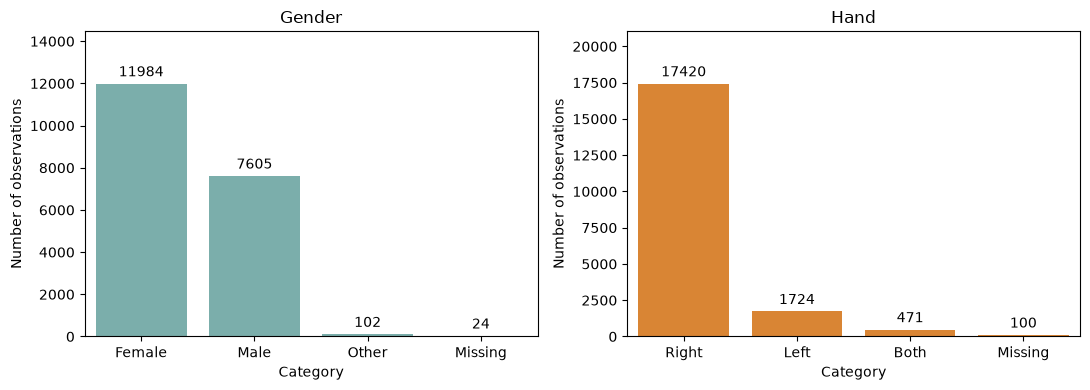

In [14]:
# Give missing categories their own label so they remain visible in the chart.
gender_for_plot = cleaned_df["gender"].fillna("Missing")
hand_for_plot = cleaned_df["hand"].fillna("Missing")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x=gender_for_plot, order=["Female", "Male", "Other", "Missing"], color="#72B7B2", ax=axes[0])
sns.countplot(x=hand_for_plot, order=["Right", "Left", "Both", "Missing"], color="#F58518", ax=axes[1])

axes[0].set_title("Gender")
axes[1].set_title("Hand")
for ax in axes:
    ax.set_xlabel("Category")
    ax.set_ylabel("Number of observations")
    ax.bar_label(ax.containers[0], padding=3)
    # Leave headroom so the count labels do not overlap the subplot titles.
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.tight_layout()
plt.show()


## 7. Focused comparison: age by target class

The box plot compares age distributions across the four target classes. Missing ages are excluded from this descriptive chart only; their rows are neither removed from the dataset nor imputed here. The chart shows distributions, not causal relationships.

In [15]:
# Use only the two needed columns and observed ages for this chart.
age_by_target = cleaned_df[[TARGET_COLUMN, "age"]].dropna()

# Complement the box plot with counts, medians, and quartiles.
age_by_target_summary = (
    age_by_target.groupby(TARGET_COLUMN)["age"]
    .describe()[["count", "mean", "25%", "50%", "75%"]]
    .reindex(TARGET_ORDER)
    .rename(columns={"count": "Count", "mean": "Mean", "25%": "Q1", "50%": "Median", "75%": "Q3"})
    .round(2)
)
age_by_target_summary


,Count,Mean,Q1,Median,Q3
target,,,,,
Moderate,8406.0,26.23,18.0,22.0,30.0
Resilient,6145.0,28.72,19.0,24.0,36.0
Overcontroller,2825.0,23.91,17.0,21.0,27.0
Undercontroller,2256.0,22.66,17.0,20.0,25.0


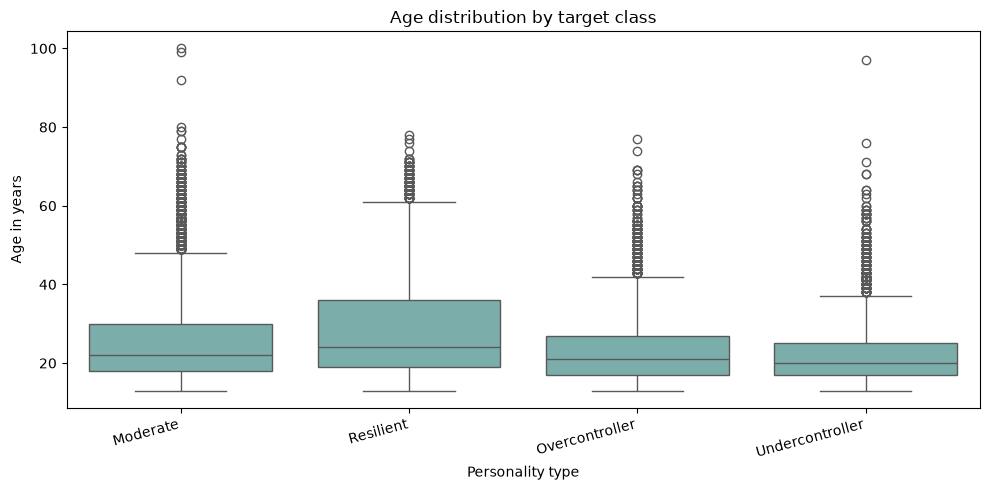

In [16]:
# Default whiskers use the 1.5-IQR rule; isolated points are statistically unusual, not automatically invalid.
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=age_by_target,
    x=TARGET_COLUMN,
    y="age",
    order=TARGET_ORDER,
    color="#72B7B2",
)
plt.title("Age distribution by target class")
plt.xlabel("Personality type")
plt.ylabel("Age in years")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


### Observations

In this sample, `Resilient` has the highest age median (24 years) and third quartile (36 years). `Undercontroller` has the lowest median (20 years), `Overcontroller` has a median of 21, and `Moderate` lies between them at 22. These differences are descriptive only. They establish neither a cause nor that `age` alone predicts the target. Age remains a numeric input to the later pipeline as specified for this project.

## 8. Target class shares by categorical feature

The following tables show the percentage composition of target classes within each category. Missing values appear as a separate group. This is descriptive analysis, not evidence of causality or a basis for another cleaning rule.

In [17]:
def target_share_by_category(dataframe, column, category_order):
    """Return target class shares within each category, including missing values."""
    categories = dataframe[column].fillna("Missing")
    return (
        pd.crosstab(categories, dataframe[TARGET_COLUMN], normalize="index")
        .reindex(index=category_order, columns=TARGET_ORDER, fill_value=0)
        .mul(100)
        .round(2)
    )

# Each row sums to 100% and describes one category.
gender_target_shares = target_share_by_category(
    cleaned_df,
    "gender",
    ["Female", "Male", "Other", "Missing"],
)
hand_target_shares = target_share_by_category(
    cleaned_df,
    "hand",
    ["Right", "Left", "Both", "Missing"],
)

print("Target class shares within gender (%)")
display(gender_target_shares)
print("Target class shares within hand (%)")
display(hand_target_shares)


Target class shares within gender (%)


target,Moderate,Resilient,Overcontroller,Undercontroller
gender,,,,
Female,48.07,26.21,15.51,10.21
Male,34.70,39.45,12.32,13.53
Other,39.22,11.76,31.37,17.65
Missing,37.50,37.50,4.17,20.83


Target class shares within hand (%)


target,Moderate,Resilient,Overcontroller,Undercontroller
hand,,,,
Right,42.94,31.19,14.32,11.54
Left,42.75,30.74,15.26,11.25
Both,40.13,35.03,12.31,12.53
Missing,42.00,33.00,13.00,12.00


### Observations and limitations

Target class composition is similar across the `hand` categories. The `Female` and `Male` distributions differ somewhat more descriptively. However, `Other` and `Missing` contain few observations and do not support robust generalizations. These tables show associations in this sample, not causes. They do not change the documented cleaning rules or how the features will be handled in the pipeline.

### Scope of the EDA

A correlation matrix, significance tests, and feature selection are deliberately outside this EDA pass. They are not established project requirements, and the 19 questionnaire features were already selected for this project. Correlation alone would not justify dropping a feature. Later cross-validation of the full pipeline provides stronger evidence about predictive performance.

## 9. Validation and export

The export must not contain `0` questionnaire values or ages above 100. Missing values in `age`, `gender`, and `hand` are intentionally retained.

In [18]:
assert cleaned_df[question_columns].isin(VALID_RESPONSE_VALUES).all().all()
assert (cleaned_df["age"].dropna() <= MAX_PLAUSIBLE_AGE).all()
assert not cleaned_df.duplicated().any()
assert cleaned_df[TARGET_COLUMN].notna().all()

missing_after_cleaning = cleaned_df.isna().sum()
print("Missing values after cleaning:")
print(missing_after_cleaning[missing_after_cleaning.gt(0)])
print("\nTarget classes after cleaning:")
print(cleaned_df[TARGET_COLUMN].value_counts())

Missing values after cleaning:
age        83
gender     24
hand      100
dtype: int64

Target classes after cleaning:
target
Moderate           8449
Resilient          6162
Overcontroller     2829
Undercontroller    2275
Name: count, dtype: int64


In [19]:
cleaned_df.to_csv(PROCESSED_PATH, index=False)
reloaded_df = pd.read_csv(PROCESSED_PATH)

assert reloaded_df.shape == cleaned_df.shape
assert list(reloaded_df.columns) == list(cleaned_df.columns)
assert reloaded_df[question_columns].isin(VALID_RESPONSE_VALUES).all().all()
assert (reloaded_df["age"].dropna() <= MAX_PLAUSIBLE_AGE).all()
assert not reloaded_df.duplicated().any()

print(f"Export validated successfully: {PROCESSED_PATH}")
print(f"Final shape: {reloaded_df.shape}")

Export validated successfully: data\data_processed.csv
Final shape: (19715, 23)
